In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # anaconda mkl + pip torch dll clash on windows - see train.ipynb

import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio, structural_similarity


In [2]:
# evaluate.ipynb - controlled synthetic-domain evaluation of the frozen model from
# train.ipynb. no training happens here: loads the frozen final checkpoint, reproduces
# the exact preprocessing/normalisation train.ipynb used, and reports cv + tv8 synthetic
# results. the training pipeline is frozen - this notebook must not retrain, tune, or
# select a different checkpoint using tv8.

VAL_SUBJECT = "TV4_20220204_sorted_UCL"
TEST_SUBJECT = "TV8_20220307_sorted_UCL"  # internal synthetic test set, evaluated once below

CROP_SIZE = 80
SCALE_FACTOR = 1.5
FWHM_PX = SCALE_FACTOR
SIGMA_REF = FWHM_PX / (2 * np.sqrt(2 * np.log(2)))  # matches train.ipynb exactly

CHANNELS = [8, 16, 32, 64]  # frozen architecture - must match the checkpoint being loaded
BATCH_SIZE = 32
SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 0

candidate_output_dirs = [Path.cwd(), Path.cwd() / "Development"]
OUTPUT_DIR = next((d / "Outputs" for d in candidate_output_dirs if (d / "Outputs").exists()), Path.cwd() / "Outputs")
EXPORT_PATH = OUTPUT_DIR / "tv_hr_crop_synthetic_lr_export.npz"
assert EXPORT_PATH.exists(), f"export file not found at {EXPORT_PATH.resolve()} - run preprocessing.ipynb's export step first"

# the FROZEN FINAL checkpoint (trained on tv1-7 for the cv-median epoch count), not the
# single-split "best" checkpoint from the earlier baseline run - this is the one model
# whose performance this notebook documents
CHECKPOINT_PATH = OUTPUT_DIR / "spatial_baseline_final.pt"
CV_SUMMARY_PATH = OUTPUT_DIR / "cv_summary.csv"
assert CHECKPOINT_PATH.exists(), f"frozen checkpoint not found at {CHECKPOINT_PATH.resolve()}"
assert CV_SUMMARY_PATH.exists(), f"cv summary not found at {CV_SUMMARY_PATH.resolve()}"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("checkpoint path:", CHECKPOINT_PATH)
print("architecture (CHANNELS):", CHANNELS)
print("sigma_ref (fixed, deterministic eval):", SIGMA_REF)


checkpoint path: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\spatial_baseline_final.pt
architecture (CHANNELS): [8, 16, 32, 64]
sigma_ref (fixed, deterministic eval): 0.6369913502160143


In [3]:
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
else:
    print("no gpu available, running on cpu")


device: cpu
no gpu available, running on cpu


In [4]:
export_data = np.load(EXPORT_PATH, allow_pickle=True)
included = export_data["included"]
hr_frames = export_data["hr_frames"][included]
subject = export_data["subject"][included]
sl = export_data["slice"][included]
dyn = export_data["dynamic"][included]
phase_bin = export_data["phase_bin"][included]
phase_direction = export_data["phase_direction"][included]

print("included frame count:", len(hr_frames))

heldout_mask = subject == TEST_SUBJECT
heldout_idx = np.where(heldout_mask)[0]
print("internal synthetic test subject:", TEST_SUBJECT, " frames:", len(heldout_idx))


included frame count: 7030
internal synthetic test subject: TV8_20220307_sorted_UCL  frames: 1140


In [5]:
# copied verbatim from train.ipynb (frozen) so the forward model is visible here rather
# than imported - never used on real iqt data (test.ipynb), only on tv frames
def degrade_hr_to_lr(image, blur_sigma=SIGMA_REF, downsample_factor=SCALE_FACTOR):
    blur_mode = "constant"
    blurred = gaussian_filter(image.astype(np.float64), sigma=blur_sigma, mode=blur_mode, cval=0.0)
    support = gaussian_filter(np.ones_like(image, dtype=np.float64), sigma=blur_sigma, mode=blur_mode, cval=0.0)
    blurred = blurred / np.maximum(support, 1e-3)

    size = image.shape[0]
    small_size = max(1, int(round(size / downsample_factor)))
    downsampled = resize(blurred, (small_size, small_size), order=3, mode="edge",
                          anti_aliasing=False, preserve_range=True)
    upsampled = resize(downsampled, (size, size), order=3, mode="edge",
                        anti_aliasing=False, preserve_range=True)
    return upsampled


In [6]:
def compute_percentile_scale(frames, subject, sl, low=1, high=99):
    scale = {}
    for key in set(zip(subject.tolist(), sl.tolist())):
        series = frames[(subject == key[0]) & (sl == key[1])]
        scale[key] = tuple(np.percentile(series, [low, high]))
    return scale


def normalise(img, lo, hi):
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0.0, 1.0)


# scaling statistics come from lr (fixed sigma_ref), not hr - reproduces train.ipynb's
# normalisation exactly, computed over the full included set so per-subject/slice
# statistics match what the checkpoint was actually trained/evaluated under
lr_frames_ref = np.stack([degrade_hr_to_lr(f, blur_sigma=SIGMA_REF) for f in hr_frames])
percentile_scale = compute_percentile_scale(lr_frames_ref, subject, sl)
print(f"percentile scaling (from lr, sigma_ref={SIGMA_REF}) computed for {len(percentile_scale)} subject/slice series")


percentile scaling (from lr, sigma_ref=0.6369913502160143) computed for 37 subject/slice series


In [7]:
class SpatialPairDataset(torch.utils.data.Dataset):
    # copied verbatim from train.ipynb - deterministic (fixed_sigma) mode only is used
    # here; augmentation is training-only and never applied during evaluation
    def __init__(self, indices, fixed_sigma):
        self.indices = indices
        self.fixed_sigma = fixed_sigma

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        hr = hr_frames[idx]
        lo, hi = percentile_scale[(subject[idx], sl[idx])]
        lr = degrade_hr_to_lr(hr, blur_sigma=self.fixed_sigma)

        hr_t = torch.from_numpy(normalise(hr, lo, hi)).float().unsqueeze(0)
        lr_t = torch.from_numpy(normalise(lr, lo, hi)).float().unsqueeze(0)
        return lr_t, hr_t


heldout_ds = SpatialPairDataset(heldout_idx, fixed_sigma=SIGMA_REF)
heldout_loader = torch.utils.data.DataLoader(heldout_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print("model input shape: (batch, 1, 80, 80)")
assert hr_frames.shape[1:] == (CROP_SIZE, CROP_SIZE)


model input shape: (batch, 1, 80, 80)


In [8]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    # unchanged from train.ipynb - 80x80 input, four downsampling levels
    def __init__(self, channels):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.pool = nn.MaxPool2d(2)
        self.enc1 = ConvBlock(1, c1)
        self.enc2 = ConvBlock(c1, c2)
        self.enc3 = ConvBlock(c2, c3)
        self.enc4 = ConvBlock(c3, c4)
        self.bottleneck = ConvBlock(c4, c4)
        self.up4 = nn.ConvTranspose2d(c4, c4, 2, stride=2)
        self.dec4 = ConvBlock(c4 + c4, c3)
        self.up3 = nn.ConvTranspose2d(c3, c3, 2, stride=2)
        self.dec3 = ConvBlock(c3 + c3, c2)
        self.up2 = nn.ConvTranspose2d(c2, c2, 2, stride=2)
        self.dec2 = ConvBlock(c2 + c2, c1)
        self.up1 = nn.ConvTranspose2d(c1, c1, 2, stride=2)
        self.dec1 = ConvBlock(c1 + c1, c1)
        self.out_conv = nn.Conv2d(c1, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


# load the frozen checkpoint - strict shape/key matching, fails loudly on any mismatch
model = UNet(CHANNELS).to(DEVICE)
state_dict = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(state_dict, strict=True)
model.eval()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"loaded frozen checkpoint from {CHECKPOINT_PATH} ({n_params} trainable parameters, CHANNELS={CHANNELS})")


loaded frozen checkpoint from C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\spatial_baseline_final.pt (232537 trainable parameters, CHANNELS=[8, 16, 32, 64])


In [9]:
def psnr_batch(pred, target):
    pred_np, target_np = pred.detach().cpu().numpy(), target.detach().cpu().numpy()
    return float(np.mean([peak_signal_noise_ratio(target_np[i, 0], pred_np[i, 0], data_range=1.0) for i in range(pred_np.shape[0])]))


def ssim_batch(pred, target):
    pred_np, target_np = pred.detach().cpu().numpy(), target.detach().cpu().numpy()
    return float(np.mean([structural_similarity(target_np[i, 0], pred_np[i, 0], data_range=1.0) for i in range(pred_np.shape[0])]))


def evaluate(model, loader):
    # inference only - no optimizer, no backward pass. also reports the degraded-lr
    # baseline so it's clear whether the model improves on the synthetic lr input
    model.eval()
    total = {"loss": 0.0, "psnr": 0.0, "ssim": 0.0, "baseline_psnr": 0.0, "baseline_ssim": 0.0}
    n = 0
    with torch.no_grad():
        for lr, hr in loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            pred_residual = model(lr)
            loss = torch.nn.functional.l1_loss(pred_residual, hr - lr)
            prediction = (lr + pred_residual).clamp(0.0, 1.0)

            bs = lr.size(0)
            total["loss"] += loss.item() * bs
            total["psnr"] += psnr_batch(prediction, hr) * bs
            total["ssim"] += ssim_batch(prediction, hr) * bs
            total["baseline_psnr"] += psnr_batch(lr, hr) * bs
            total["baseline_ssim"] += ssim_batch(lr, hr) * bs
            n += bs
    return {k: v / n for k, v in total.items()}


In [10]:
# --- untouched synthetic tv8 test - the frozen model, evaluated exactly once ---
final_test_metrics = evaluate(model, heldout_loader)
test_l1 = final_test_metrics["loss"]  # this is TEST l1, not validation l1 - tv8 was never used for model selection

print("tv8 internal synthetic test (frozen final checkpoint):")
print(f"  test L1:            {test_l1:.4f}")
print(f"  model PSNR:         {final_test_metrics['psnr']:.2f} dB")
print(f"  model SSIM:         {final_test_metrics['ssim']:.4f}")
print(f"  degraded-LR baseline PSNR: {final_test_metrics['baseline_psnr']:.2f} dB")
print(f"  degraded-LR baseline SSIM: {final_test_metrics['baseline_ssim']:.4f}")

delta_psnr = final_test_metrics["psnr"] - final_test_metrics["baseline_psnr"]
delta_ssim = final_test_metrics["ssim"] - final_test_metrics["baseline_ssim"]
print(f"\n  delta PSNR (model - baseline): {delta_psnr:+.2f} dB")
print(f"  delta SSIM (model - baseline): {delta_ssim:+.4f}")

# sanity check against the previously reported values for this run - report any
# discrepancy rather than assuming a match
expected = {"psnr": 30.28, "ssim": 0.9677, "loss": 0.0186, "baseline_psnr": 27.31, "baseline_ssim": 0.9391}
print("\ncomparison against previously reported values:")
for key, exp_val in expected.items():
    actual = test_l1 if key == "loss" else final_test_metrics[key]
    print(f"  {key}: expected~{exp_val}  actual={actual:.4f}  diff={actual - exp_val:+.4f}")


tv8 internal synthetic test (frozen final checkpoint):
  test L1:            0.0186
  model PSNR:         30.28 dB
  model SSIM:         0.9677
  degraded-LR baseline PSNR: 27.31 dB
  degraded-LR baseline SSIM: 0.9391

  delta PSNR (model - baseline): +2.98 dB
  delta SSIM (model - baseline): +0.0286

comparison against previously reported values:
  psnr: expected~30.28  actual=30.2826  diff=+0.0026
  ssim: expected~0.9677  actual=0.9677  diff=+0.0000
  loss: expected~0.0186  actual=0.0186  diff=+0.0000
  baseline_psnr: expected~27.31  actual=27.3059  diff=-0.0041
  baseline_ssim: expected~0.9391  actual=0.9391  diff=-0.0000


In [11]:
# --- subject-level leave-one-out cv across tv1-tv7 (already computed, loaded not rerun) ---
cv_summary = pd.read_csv(CV_SUMMARY_PATH)
print(cv_summary.to_string(index=False))

psnr_mean, psnr_sd = cv_summary["best_psnr"].mean(), cv_summary["best_psnr"].std()
ssim_mean, ssim_sd = cv_summary["ssim"].mean(), cv_summary["ssim"].std()
best_epochs = cv_summary["best_epoch"].to_numpy()

print(f"\nmean PSNR: {psnr_mean:.2f} +/- {psnr_sd:.2f} dB")
print(f"mean SSIM: {ssim_mean:.4f} +/- {ssim_sd:.4f}")
print(f"best epoch - mean: {best_epochs.mean():.2f}  median: {np.median(best_epochs):.1f}  "
      f"range: {best_epochs.min()}-{best_epochs.max()}")

final_epoch_used = int(round(float(np.median(best_epochs))))
print(f"\nmedian best epoch (= final training epoch count used for the frozen checkpoint): {final_epoch_used}")
assert final_epoch_used == 28, f"expected the frozen final epoch count to be 28, got {final_epoch_used} - cv_summary.csv may have changed"


     validation_subject  best_epoch  best_psnr     ssim   val_l1
TV1_20220222_sorted_UCL          30  31.296970 0.975042 0.015795
TV2_20220222_sorted_UCL          28  32.271570 0.982143 0.013065
TV3_20220208_sorted_UCL          25  31.016356 0.976749 0.016802
TV4_20220204_sorted_UCL          21  31.326527 0.970791 0.014961
TV5_20220307_sorted_UCL          30  31.150916 0.975986 0.015765
TV6_20220307_sorted_UCL          19  29.349706 0.948307 0.022227
TV7_20220315_sorted_UCL          29  32.178884 0.976965 0.013178

mean PSNR: 31.23 +/- 0.96 dB
mean SSIM: 0.9723 +/- 0.0111
best epoch - mean: 26.00  median: 28.0  range: 19-30

median best epoch (= final training epoch count used for the frozen checkpoint): 28


saved: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\evaluate_tv8_qualitative_examples.png


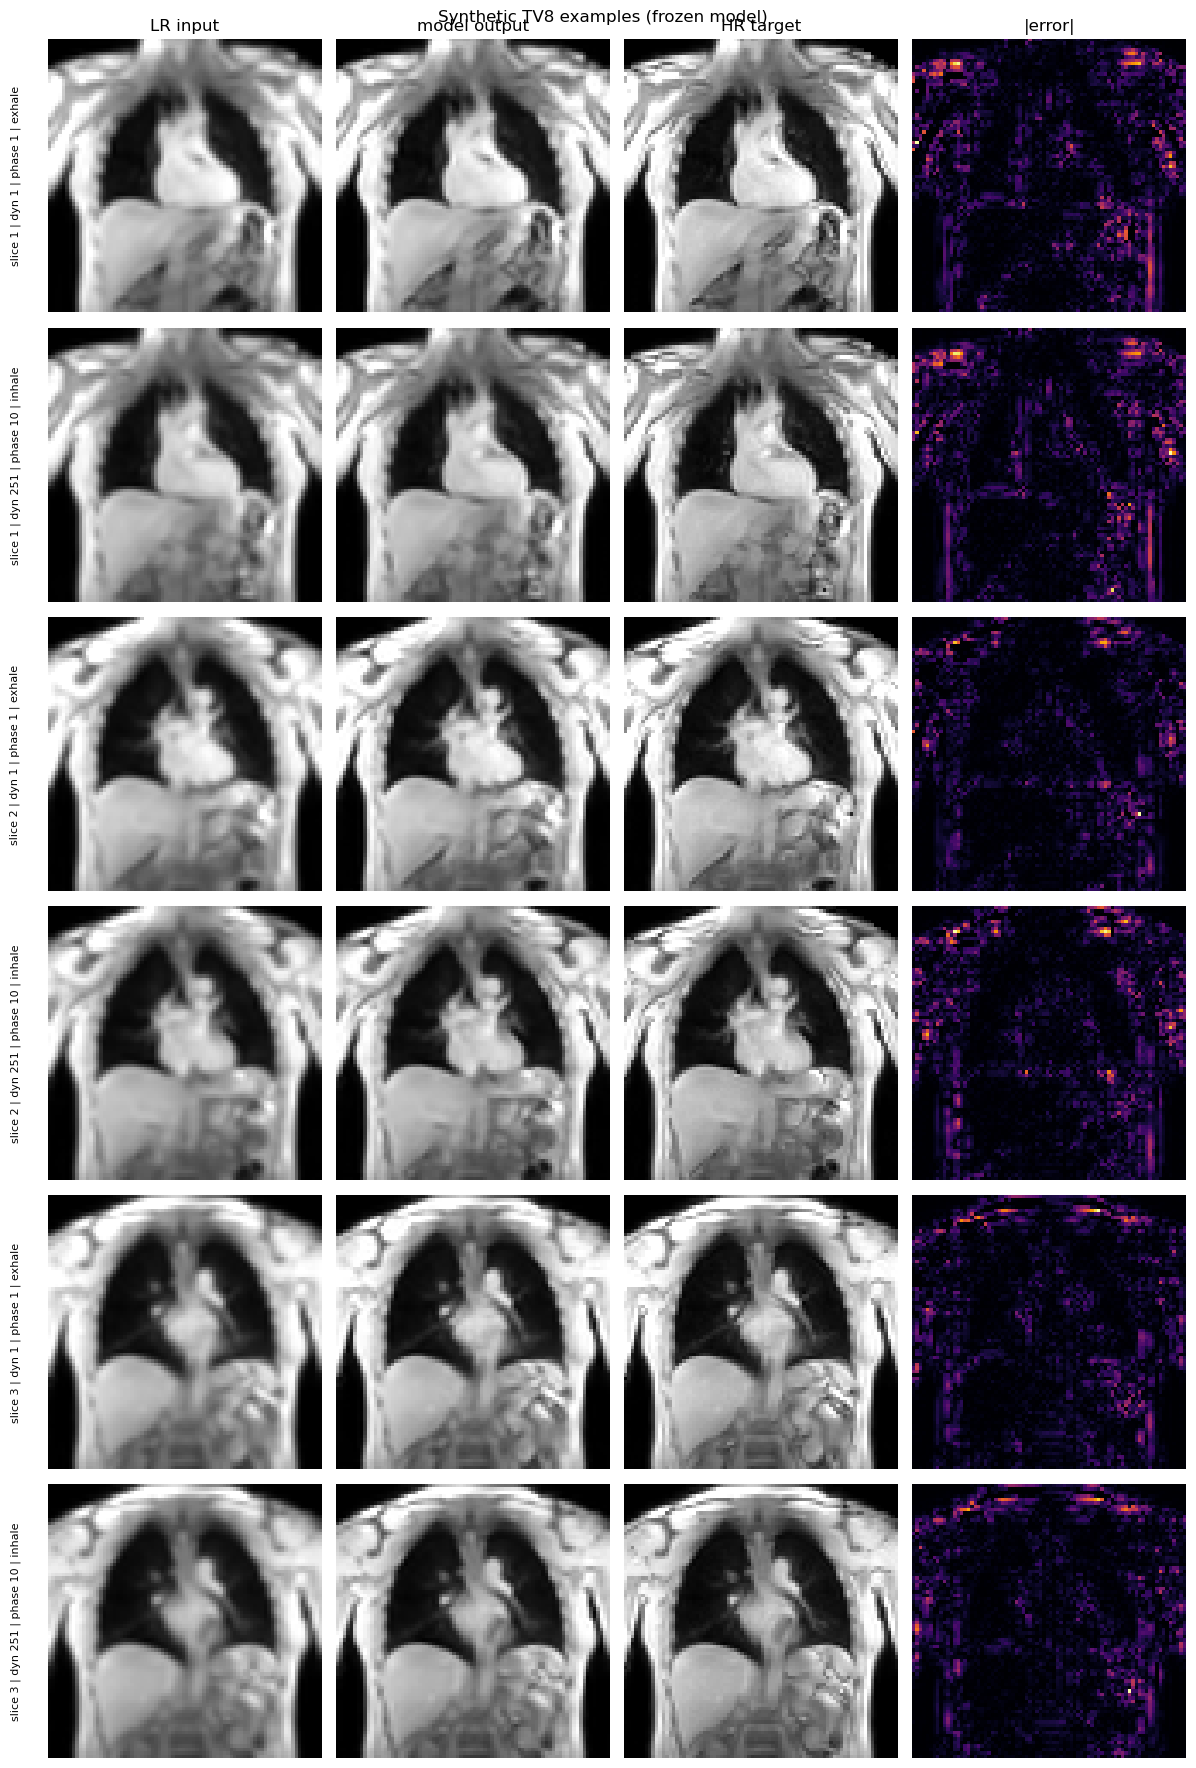

In [12]:
# --- qualitative synthetic examples: lr | prediction | hr | absolute error ---
# deterministic selection spanning slices and phase bins - not manually cherry-picked
heldout_sl = sl[heldout_idx]
heldout_phase = phase_bin[heldout_idx]
example_slices = sorted(set(heldout_sl.tolist()))[:3]

example_positions = []
for s in example_slices:
    in_slice = np.where(heldout_sl == s)[0]
    # deterministic: the frames closest to the min and max phase_bin seen on this slice.
    # a handful of tv8 frames have phase_bin=nan (no valid respiratory half-cycle assigned -
    # see the "direction" breakdown below) - argmin/argmax on an array containing nan
    # keep returning a nan entry's own position regardless of the true min/max, so those
    # frames are excluded from THIS selection specifically (not from the metrics above)
    phases = heldout_phase[in_slice]
    valid = ~np.isnan(phases)
    if not valid.any():
        continue
    valid_local = in_slice[valid]
    valid_phases = phases[valid]
    example_positions.append(valid_local[np.argmin(valid_phases)])
    example_positions.append(valid_local[np.argmax(valid_phases)])

fig, axes = plt.subplots(len(example_positions), 4, figsize=(12, 3 * len(example_positions)))
model.eval()
with torch.no_grad():
    for row, pos in enumerate(example_positions):
        lr_t, hr_t = heldout_ds[pos]
        pred_residual = model(lr_t.unsqueeze(0).to(DEVICE))
        prediction = (lr_t.to(DEVICE) + pred_residual[0]).clamp(0.0, 1.0)

        lr_img = lr_t[0].numpy()
        hr_img = hr_t[0].numpy()
        pred_img = prediction[0].detach().cpu().numpy()
        abs_err = np.abs(pred_img - hr_img)

        vmax = max(lr_img.max(), hr_img.max(), pred_img.max())
        idx = heldout_idx[pos]
        titles = [f"LR input", f"model output", f"HR target", f"|error|"]
        imgs = [lr_img, pred_img, hr_img, abs_err]
        for col, (img, title) in enumerate(zip(imgs, titles)):
            cmap = "gray" if col < 3 else "inferno"
            v = vmax if col < 3 else abs_err.max()
            axes[row, col].imshow(img, cmap=cmap, vmin=0, vmax=v)
            if row == 0:
                axes[row, col].set_title(title)
            axes[row, col].axis("off")
        axes[row, 0].text(-0.1, 0.5, f"slice {sl[idx]} | dyn {dyn[idx]} | phase {phase_bin[idx]:.0f} | {phase_direction[idx]}",
                           transform=axes[row, 0].transAxes, ha="right", va="center", fontsize=8, rotation=90)

fig.suptitle("Synthetic TV8 examples (frozen model)", fontsize=12)
plt.tight_layout()
synth_examples_path = OUTPUT_DIR / "evaluate_tv8_qualitative_examples.png"
fig.savefig(synth_examples_path, dpi=120, bbox_inches="tight")
print(f"saved: {synth_examples_path}")
plt.show()


In [13]:
# --- tv8 performance by slice / phase bin / direction (metadata already exists in the export) ---
per_frame_rows = []
model.eval()
with torch.no_grad():
    for pos in range(len(heldout_idx)):
        lr_t, hr_t = heldout_ds[pos]
        lr_b, hr_b = lr_t.unsqueeze(0).to(DEVICE), hr_t.unsqueeze(0).to(DEVICE)
        pred_residual = model(lr_b)
        prediction = (lr_b + pred_residual).clamp(0.0, 1.0)
        idx = heldout_idx[pos]
        per_frame_rows.append({
            "slice": int(sl[idx]), "dynamic": int(dyn[idx]),
            "phase_bin": float(phase_bin[idx]), "direction": str(phase_direction[idx]),
            "psnr": psnr_batch(prediction, hr_b), "ssim": ssim_batch(prediction, hr_b),
        })
per_frame_df = pd.DataFrame(per_frame_rows)

print("tv8 psnr/ssim by slice:")
print(per_frame_df.groupby("slice")[["psnr", "ssim"]].agg(["mean", "std", "count"]))

print("\ntv8 psnr/ssim by phase bin:")
print(per_frame_df.groupby("phase_bin")[["psnr", "ssim"]].agg(["mean", "count"]))

print("\ntv8 psnr/ssim by direction:")
print(per_frame_df.groupby("direction")[["psnr", "ssim"]].agg(["mean", "std", "count"]))

per_frame_csv_path = OUTPUT_DIR / "evaluate_tv8_per_frame_metrics.csv"
per_frame_df.to_csv(per_frame_csv_path, index=False)
print(f"\nsaved: {per_frame_csv_path}")


tv8 psnr/ssim by slice:
            psnr                      ssim                
            mean       std count      mean       std count
slice                                                     
1      28.004775  0.204705   190  0.959246  0.002269   190
2      28.870343  0.143686   190  0.966665  0.001443   190
3      29.979537  0.165974   190  0.971221  0.001224   190
4      30.145200  0.176681   190  0.964241  0.001220   190
5      30.638533  0.182148   190  0.966886  0.001261   190
6      34.057357  0.154686   190  0.978091  0.000758   190

tv8 psnr/ssim by phase bin:
                psnr            ssim      
                mean count      mean count
phase_bin                                 
1.0        30.292249   822  0.967773   822
2.0        30.211451    12  0.967440    12
3.0        30.201916     6  0.967682     6
4.0        30.329074    18  0.967985    18
5.0        30.242968   216  0.967447   216
6.0        30.302070    12  0.967842    12
7.0        30.304131    12  0

In [14]:
# --- final summary ---
print("=== evaluate.ipynb summary ===")
print(f"checkpoint: {CHECKPOINT_PATH}")
print(f"architecture: {CHANNELS}")
print(f"cv folds: {len(cv_summary)}  mean_psnr={psnr_mean:.2f}+/-{psnr_sd:.2f}  mean_ssim={ssim_mean:.4f}+/-{ssim_sd:.4f}  median_best_epoch={final_epoch_used}")
print(f"tv8 synthetic test: n={len(heldout_idx)}  test_l1={test_l1:.4f}  psnr={final_test_metrics['psnr']:.2f}  ssim={final_test_metrics['ssim']:.4f}")
print(f"tv8 baseline (degraded lr): psnr={final_test_metrics['baseline_psnr']:.2f}  ssim={final_test_metrics['baseline_ssim']:.4f}")
print(f"delta vs baseline: psnr={delta_psnr:+.2f}  ssim={delta_ssim:+.4f}")


=== evaluate.ipynb summary ===
checkpoint: C:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\spatial_baseline_final.pt
architecture: [8, 16, 32, 64]
cv folds: 7  mean_psnr=31.23+/-0.96  mean_ssim=0.9723+/-0.0111  median_best_epoch=28
tv8 synthetic test: n=1140  test_l1=0.0186  psnr=30.28  ssim=0.9677
tv8 baseline (degraded lr): psnr=27.31  ssim=0.9391
delta vs baseline: psnr=+2.98  ssim=+0.0286
